In [10]:
import yfinance as yf
import pandas as pd

# 분석 대상 ETF
tickers = ["SPY", "QQQ", "TLT"]

# 데이터 다운로드
data = yf.download(
    tickers,
    start="2015-01-01",
    end="2024-12-31"
)

# 확인
print(data.head())

[*********************100%***********************]  3 of 3 completed

Price           Close                              High              \
Ticker            QQQ         SPY        TLT        QQQ         SPY   
Date                                                                  
2015-01-02  94.665077  170.124969  93.712074  95.823786  171.325784   
2015-01-05  93.276489  167.052612  95.184181  94.361635  169.247181   
2015-01-06  92.025772  165.479111  96.899132  93.570724  167.880714   
2015-01-07  93.212090  167.541214  96.707748  93.432795  167.880755   
2015-01-08  94.996147  170.514236  95.427040  95.180067  170.729561   

Price                        Low                              Open  \
Ticker            TLT        QQQ         SPY        TLT        QQQ   
Date                                                                 
2015-01-02  93.962329  94.205270  169.089793  92.850914  95.419160   
2015-01-05  95.412351  93.009800  166.746204  94.183166  94.251278   
2015-01-06  97.517411  91.611949  164.684090  95.824526  93.414391   
2015-01-07 

In [11]:
import sys
!{sys.executable} -m pip install pandas yfinance ipykernel


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
price = data["Close"].copy()
print(price.head())

Ticker            QQQ         SPY        TLT
Date                                        
2015-01-02  94.665077  170.124969  93.712074
2015-01-05  93.276489  167.052612  95.184181
2015-01-06  92.025772  165.479111  96.899132
2015-01-07  93.212090  167.541214  96.707748
2015-01-08  94.996147  170.514236  95.427040


In [13]:
price.to_csv("etf_price.csv")

In [14]:
import sys
!{sys.executable} -m pip install matplotlib seaborn numpy ipykernel


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


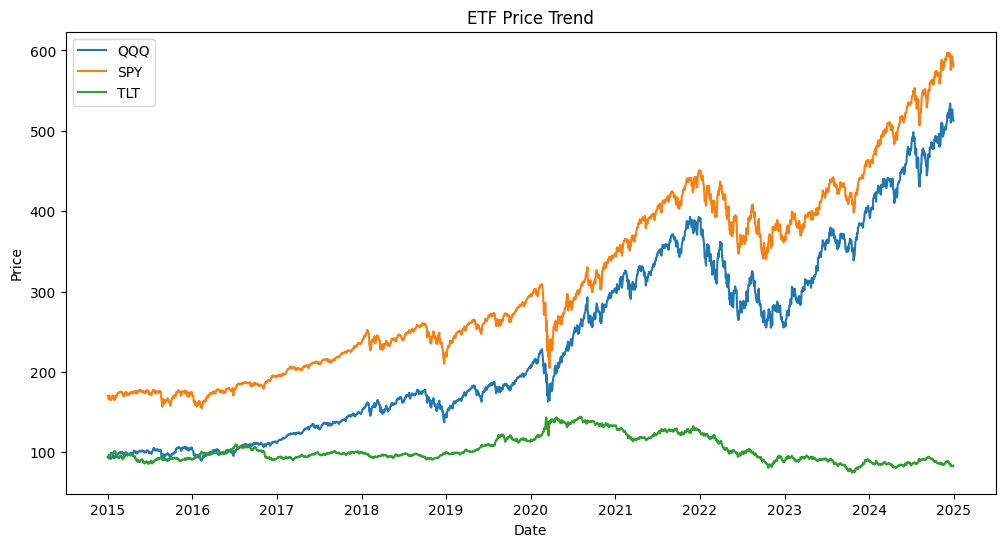

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for col in price.columns:
    plt.plot(price.index, price[col], label=col)

plt.title("ETF Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# Week 3 — 자산 가격 분석

## 목표
ETF 가격 데이터를 다양한 각도에서 시각화하여 각 자산의 특성과 관계를 파악한다.

## 분석 항목
1. 정규화 가격 차트 — 시작일 기준 100으로 맞춰 자산 간 성장률 비교
2. 이동평균선 — 50일·200일 추세 확인
3. 상관관계 히트맵 — 자산 간 동조화 여부
4. 연도별 연간 수익률 — 각 자산의 해마다 성과 비교

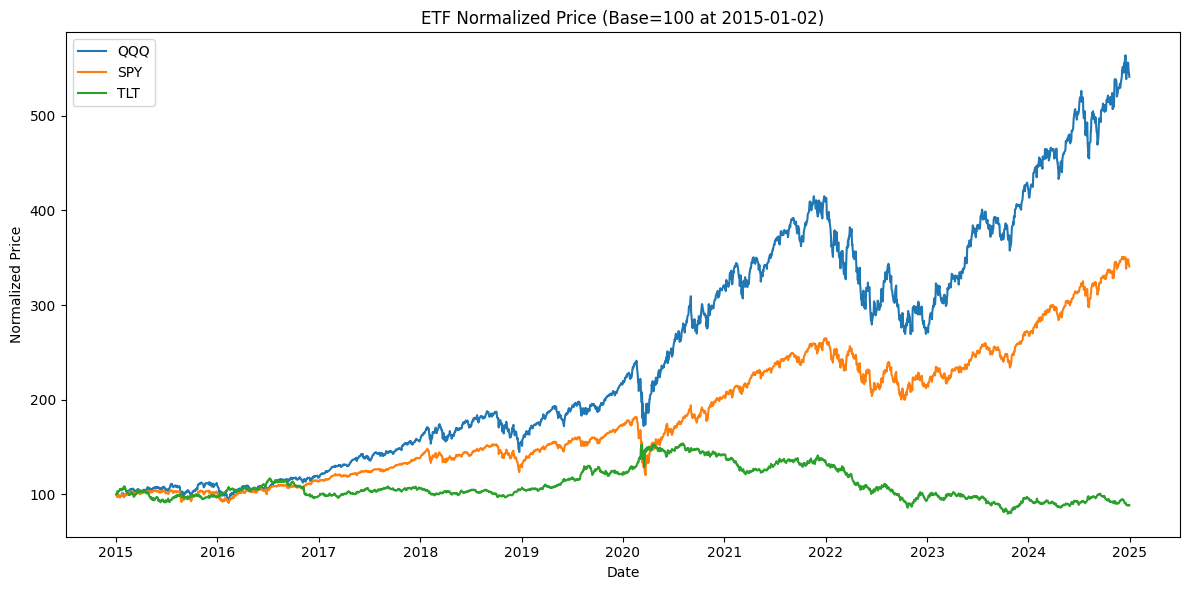

2015 → 2024 누적 성장률:
  QQQ: +441.2%
  SPY: +240.8%
  TLT: +-11.3%


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

price = pd.read_csv("etf_price.csv", index_col="Date", parse_dates=True)

# 정규화: 시작일 기준 100
normalized = price / price.iloc[0] * 100

plt.figure(figsize=(12, 6))
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col)

plt.title("ETF Normalized Price (Base=100 at 2015-01-02)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

print("2015 → 2024 누적 성장률:")
for col in normalized.columns:
    growth = normalized[col].iloc[-1] - 100
    print(f"  {col}: +{growth:.1f}%")

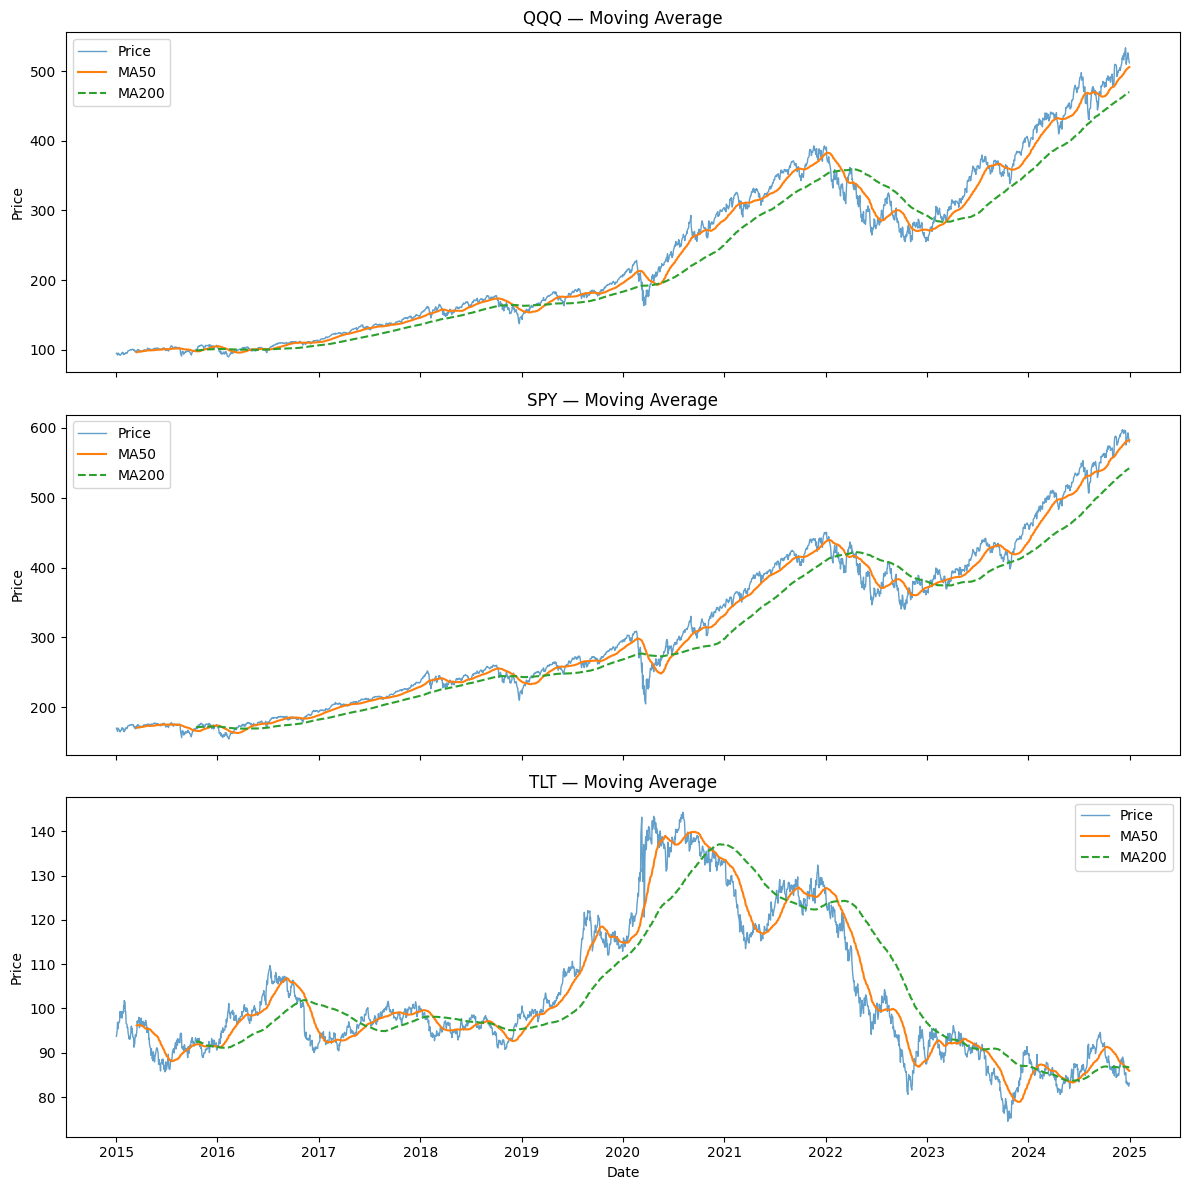

In [2]:
# 이동평균선: SPY 기준으로 50일 / 200일 추세 확인
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for ax, col in zip(axes, price.columns):
    ma50 = price[col].rolling(50).mean()
    ma200 = price[col].rolling(200).mean()

    ax.plot(price.index, price[col], label="Price", linewidth=1, alpha=0.7)
    ax.plot(price.index, ma50, label="MA50", linewidth=1.5)
    ax.plot(price.index, ma200, label="MA200", linewidth=1.5, linestyle="--")

    ax.set_title(f"{col} — Moving Average")
    ax.set_ylabel("Price")
    ax.legend()

plt.xlabel("Date")
plt.tight_layout()
plt.show()

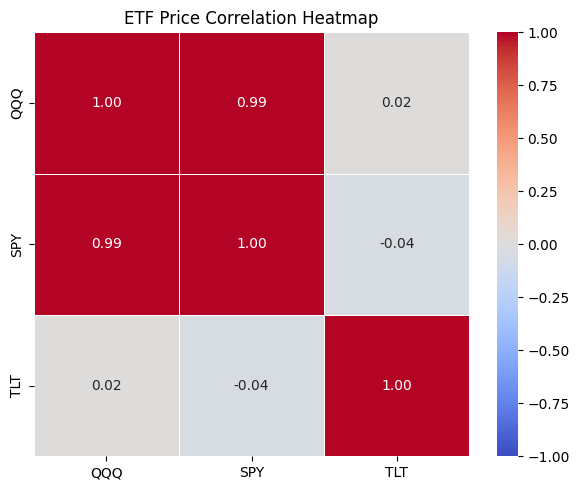

상관계수 해석:
  SPY ↔ QQQ: 0.99  → 강한 양의 상관 (함께 오르고 내림)
  SPY ↔ TLT: -0.04  → 음의 상관 (주식과 채권은 반대 방향)
  QQQ ↔ TLT: 0.02  → 음의 상관


In [3]:
import seaborn as sns

corr = price.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.5)
plt.title("ETF Price Correlation Heatmap")
plt.tight_layout()
plt.show()

print("상관계수 해석:")
print(f"  SPY ↔ QQQ: {corr.loc['SPY','QQQ']:.2f}  → 강한 양의 상관 (함께 오르고 내림)")
print(f"  SPY ↔ TLT: {corr.loc['SPY','TLT']:.2f}  → 음의 상관 (주식과 채권은 반대 방향)")
print(f"  QQQ ↔ TLT: {corr.loc['QQQ','TLT']:.2f}  → 음의 상관")

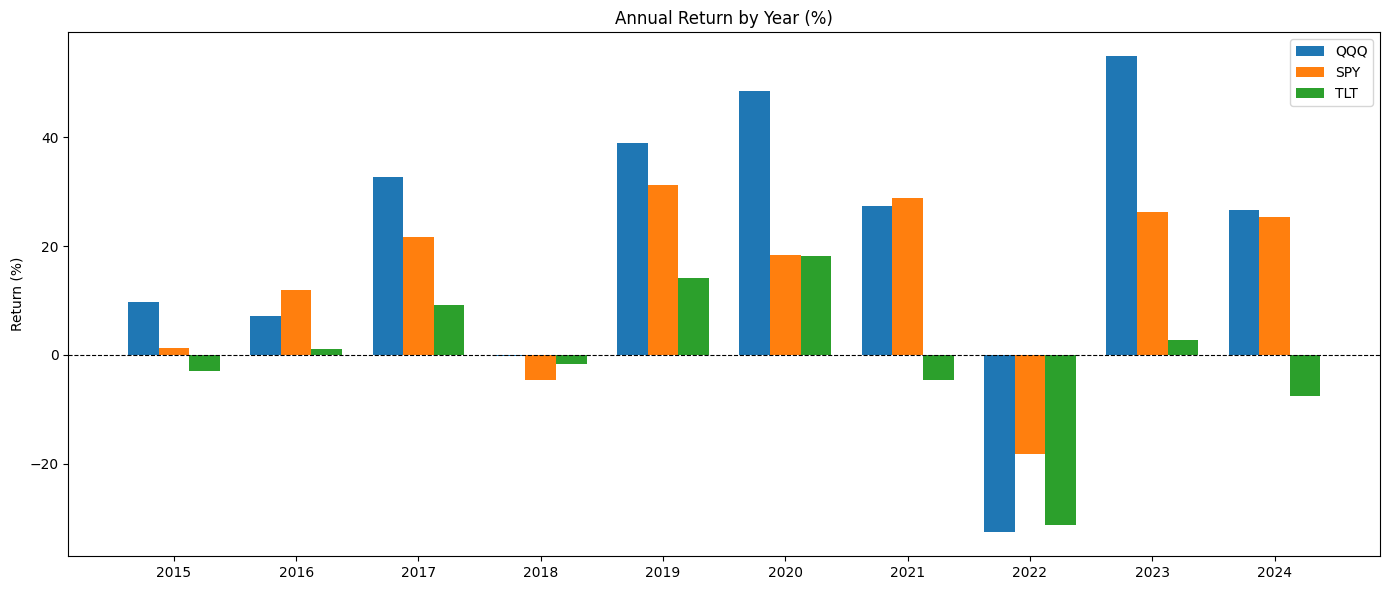


연도별 수익률 요약 (%):
       QQQ   SPY   TLT
Date                  
2015   9.8   1.3  -2.9
2016   7.1  12.0   1.2
2017  32.7  21.7   9.2
2018  -0.1  -4.6  -1.6
2019  39.0  31.2  14.1
2020  48.4  18.3  18.2
2021  27.4  28.7  -4.6
2022 -32.6 -18.2 -31.2
2023  54.9  26.2   2.8
2024  26.7  25.3  -7.6


In [4]:
import numpy as np

# 연도별 연간 수익률 계산
returns_daily = price.pct_change().dropna()
annual_return = returns_daily.groupby(returns_daily.index.year).apply(
    lambda x: (1 + x).prod() - 1
) * 100

x = np.arange(len(annual_return.index))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
for i, col in enumerate(annual_return.columns):
    ax.bar(x + i * width, annual_return[col], width, label=col)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x + width)
ax.set_xticklabels(annual_return.index)
ax.set_title("Annual Return by Year (%)")
ax.set_ylabel("Return (%)")
ax.legend()
plt.tight_layout()
plt.show()

print("\n연도별 수익률 요약 (%):")
print(annual_return.round(1).to_string())

## Week 3 정리

### 핵심 관찰

- **정규화 차트**: QQQ가 10년간 가장 높은 성장률, TLT는 상대적으로 낮고 변동이 적음
- **이동평균선**: QQQ·SPY는 장기 우상향 추세, TLT는 2022년 이후 하락 국면 진입
- **상관관계**: SPY↔QQQ 상관이 매우 높음 → 두 자산을 함께 보유해도 분산 효과 제한적  
  TLT는 주식과 음의 상관 → 포트폴리오에 섞으면 리스크 완화 가능성 있음
- **연도별 수익률**: 2022년에 주식(SPY·QQQ)과 채권(TLT)이 동시에 하락 (금리 급등 영향)

### 다음 회차 예고 (4회차)
일별 수익률·누적 수익률 계산으로 자산별 성과를 정량적으로 비교한다.

위 코드까지 한 것
# Week 2 — Data Collection

## Objective
Collect financial data and understand its structure for portfolio analysis.

## Data Collection
- Source: Yahoo Finance (yfinance)
- Assets: SPY, QQQ, TLT
- Period: 2015–2024

## Data Structure
- MultiIndex columns:
  - Level 1: Price (Open, High, Low, Close, Volume)
  - Level 2: Ticker (SPY, QQQ, TLT)

## Preprocessing
- Extract closing prices:
```python
price = data["Close"].copy()

# Week 4 — 수익률 분석

## 목표
일별 수익률과 누적 수익률을 계산하고, QQQ·SPY·TLT의 성과를 정량적으로 비교한다.

## 구현 내용
- 전일 대비 가격 변화율로 일별 수익률 계산
- 누적 수익률과 연율화 평균 수익률 계산
- 수익률 분포, 누적 수익률, 연율화 수익률, 요약표 이미지 생성
- 결과 파일은 `outputs/week4`에 저장

In [ ]:
%run scripts/week4_return_analysis.py

## Week 4 분석 정리

![Daily return distribution](outputs/week4/daily_return_distribution.png)

![Cumulative return](outputs/week4/cumulative_return.png)

![Annualized return](outputs/week4/annualized_return_bar.png)

![Return summary table](outputs/week4/return_summary_table.png)

2015년부터 2024년까지의 종가를 기준으로 일별 수익률을 계산한 결과, QQQ와 SPY는 장기적으로 뚜렷한 양의 수익률을 보였고 TLT는 분석 기간 전체에서 성장성이 약했다. 일별 수익률 분포는 세 자산 모두 0% 근처에 집중되어 있지만, QQQ와 SPY는 큰 상승일과 하락일이 더 넓게 분포해 주식 ETF 특유의 변동성을 보인다.

누적 수익률 기준으로는 QQQ가 가장 높은 성과를 냈고 SPY가 그 뒤를 따른다. TLT는 2022년 이후 금리 상승 구간의 약세 영향이 크게 반영되며 누적 수익률이 음수로 마감했다. 따라서 단순 수익률 관점에서는 QQQ가 가장 우수하지만, 일별 변동성도 가장 크기 때문에 이 결과만으로 최적 자산이라고 결론내릴 수는 없다.

4주차 결론은 수익률 성과의 순위가 QQQ, SPY, TLT 순으로 명확하다는 것이다. 다만 다음 단계에서는 변동성, 최대 낙폭, Sharpe Ratio를 함께 계산해 높은 수익률이 실제로 감수한 위험 대비 효율적인 성과였는지 확인해야 한다.

# Week 5 — 리스크 분석

## 목표
수익률만으로 판단하기 어려운 자산별 위험을 변동성, 최대 낙폭, 롤링 변동성으로 측정한다.

## 구현 내용
- 연율화 변동성 계산
- 누적 수익률 기준 최대 낙폭 계산
- 252일 롤링 변동성 계산
- 리스크 요약표와 시각화 이미지를 `outputs/week5`에 저장

In [ ]:
%run scripts/week5_risk_analysis.py

## Week 5 분석 정리

![Annualized volatility](outputs/week5/annualized_volatility_bar.png)

![Drawdown over time](outputs/week5/max_drawdown_chart.png)

![Maximum drawdown](outputs/week5/max_drawdown_bar.png)

![Rolling volatility](outputs/week5/rolling_volatility_chart.png)

![Risk summary table](outputs/week5/risk_summary_table.png)

5주차에서는 일별 수익률의 표준편차를 연율화해 변동성을 계산하고, 누적 수익률이 직전 고점 대비 얼마나 하락했는지 최대 낙폭으로 측정했다. 이 분석은 4주차에서 확인한 높은 수익률이 어느 정도의 위험을 감수한 결과인지 판단하기 위한 단계다.

결과적으로 QQQ는 가장 높은 누적 수익률을 보였지만 연율화 변동성도 가장 컸다. SPY는 QQQ보다 수익률은 낮지만 변동성도 낮아 중간 수준의 위험·수익 특성을 보인다. TLT는 주식 ETF보다 낮은 변동성을 보였지만, 2022년 이후 금리 상승 구간에서 최대 낙폭이 크게 확대되어 항상 안정적인 방어 자산이라고 단정하기 어렵다.

롤링 변동성 차트에서는 2020년 코로나19 충격과 2022년 금리 상승 구간에서 위험이 크게 증가했다. 따라서 6주차 포트폴리오 전략 분석에서는 단순히 수익률이 높은 자산만 선택하지 않고, QQQ 단일 전략, SPY+QQQ 주식 혼합 전략, SPY+TLT 주식+채권 전략을 비교해 리스크 완화 효과를 검증해야 한다.

# Week 6 — 포트폴리오 전략 분석

## 목표
세 가지 고정 비중 전략을 구성하고 수익률, 변동성, 최대 낙폭, Sharpe Ratio를 비교한다.

## 전략 정의
- 전략 A: QQQ 100%
- 전략 B: SPY 50% + QQQ 50%
- 전략 C: SPY 60% + TLT 40%

## 구현 내용
- 전략별 일별 포트폴리오 수익률 계산
- 누적 수익률, 연율화 수익률, 변동성, MDD, Sharpe Ratio 계산
- 전략 비교 차트와 요약표를 `outputs/week6`에 저장

In [ ]:
%run scripts/week6_portfolio_strategy_analysis.py

## Week 6 분석 정리

![Strategy weights](outputs/week6/strategy_weights_table.png)

![Strategy cumulative return](outputs/week6/strategy_cumulative_return.png)

![Risk return comparison](outputs/week6/strategy_risk_return_scatter.png)

![Sharpe ratio](outputs/week6/strategy_sharpe_ratio_bar.png)

![Strategy drawdown](outputs/week6/strategy_drawdown.png)

![Performance summary](outputs/week6/strategy_performance_table.png)

6주차에서는 QQQ 단일 전략, SPY+QQQ 주식 혼합 전략, SPY+TLT 주식+채권 전략을 구성해 포트폴리오 단위의 성과를 비교했다. 무위험 수익률은 연 3%로 가정했고, 각 전략의 연율화 수익률과 변동성을 바탕으로 Sharpe Ratio를 계산했다.

전략 A는 QQQ 100%이므로 누적 수익률이 가장 높지만 변동성과 낙폭도 가장 크게 나타난다. 전략 B는 QQQ와 SPY를 절반씩 섞어 성장성을 유지하면서 집중 위험을 낮추는 절충안이다. 전략 C는 TLT를 40% 편입해 변동성을 낮추는 구조지만, 분석 기간에는 TLT의 장기 부진과 2022년 이후 채권 약세 때문에 성과 개선 효과가 제한적이었다.

결론적으로 단순 수익률만 보면 전략 A가 우세하지만, 위험 대비 성과 관점에서는 전략 B가 더 균형적인 선택지다. 다음 7주차에서는 고정된 세 전략을 넘어 무작위 비중 조합을 생성하고 Efficient Frontier와 최적 포트폴리오를 도출한다.

# Week 7 — 포트폴리오 최적화

## 목표
SPY·QQQ·TLT의 랜덤 비중 조합 10,000개를 생성하고 Efficient Frontier를 시각화해 최적 포트폴리오를 찾는다.

## 구현 내용
- Monte Carlo 방식으로 랜덤 비중 10,000개 생성
- 각 조합의 기대 수익률, 변동성, Sharpe Ratio 계산
- Max Sharpe Portfolio와 Min Volatility Portfolio 식별
- Efficient Frontier와 최적 비중 결과를 `outputs/week7`에 저장

In [ ]:
%run scripts/week7_portfolio_optimization.py

## Week 7 분석 정리

![Efficient frontier](outputs/week7/efficient_frontier.png)

![Optimal weights](outputs/week7/optimal_weights_bar.png)

![Optimal cumulative return](outputs/week7/optimal_cumulative_return.png)

![Optimal summary](outputs/week7/optimal_portfolio_summary_table.png)

7주차에서는 SPY, QQQ, TLT의 비중 합계가 100%가 되도록 랜덤 포트폴리오 10,000개를 만들고, 각 조합의 연율화 수익률, 연율화 변동성, Sharpe Ratio를 계산했다. Efficient Frontier는 변동성이 커질수록 기대 수익률도 높아지는 경향을 보여주지만, 같은 위험 수준에서도 Sharpe Ratio 차이가 존재한다.

Max Sharpe Portfolio는 위험 대비 수익 효율이 가장 높은 조합이며, QQQ의 성장성을 활용하면서 SPY와 TLT를 일부 결합하는 구조로 나타난다. Min Volatility Portfolio는 변동성 자체를 최소화하는 조합이므로 TLT 비중이 크게 증가하지만, 분석 기간의 TLT 성과 부진 때문에 누적 성과는 제한적이다.

결론적으로 최적화 기준이 Sharpe Ratio인지 변동성 최소화인지에 따라 선택되는 포트폴리오가 달라진다. 최종 8주차에서는 6주차의 수동 전략 3개와 7주차의 최적화 전략 2개를 통합 비교해 투자자 성향별 추천안을 정리한다.

# Week 8 — 최종 결과 정리 및 전략 제안

## 목표
수동 전략 3개와 최적화 전략 2개를 통합 비교하고 투자자 성향별 최종 포트폴리오를 제안한다.

## 구현 내용
- Strategy A, B, C와 Max Sharpe, Min Volatility 전략 통합 비교
- 누적 수익률, 변동성, 최대 낙폭, Sharpe Ratio 기준 최종 테이블 생성
- 공격형, 중립형, 안정형 투자자별 추천 전략 정리
- 최종 보고서와 발표용 요약 노트를 `outputs/week8`에 저장

In [ ]:
%run scripts/week8_final_strategy_recommendation.py

## Week 8 최종 정리

![Final strategy comparison](outputs/week8/final_strategy_comparison_table.png)

![Final cumulative return comparison](outputs/week8/final_cumulative_return_comparison.png)

![Final risk return map](outputs/week8/final_risk_return_map.png)

![Sharpe and MDD comparison](outputs/week8/final_sharpe_mdd_comparison.png)

![Investor recommendations](outputs/week8/investor_recommendations_table.png)

8주차에서는 수동 전략 3개와 최적화 전략 2개를 같은 기준으로 비교했다. QQQ 중심 전략은 가장 높은 수익률과 Sharpe Ratio를 보였지만 최대 낙폭도 컸다. Strategy B는 QQQ와 SPY를 섞어 성장성과 리스크 완화의 균형을 만든다. Strategy C는 채권 ETF를 포함해 방어적 성격을 갖지만 금리 상승 구간에서는 TLT 리스크가 나타났다.

최종 추천은 투자자 성향별로 나누는 것이 적절하다. 공격형은 높은 낙폭을 감수하고 Strategy A 또는 Max Sharpe를 선택할 수 있다. 중립형은 Strategy B가 가장 현실적인 균형형 전략이다. 안정형은 단순 변동성 최소화보다 실제 성과와 낙폭이 더 나은 Strategy C가 적합하다.

전체 결론은 수익률, 변동성, 최대 낙폭, Sharpe Ratio를 함께 고려해야 한다는 것이다. 하나의 절대적 최적 포트폴리오는 없으며, 투자자의 위험 감내도에 따라 적절한 전략이 달라진다.